Conditional Agent

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    num1: int
    num2: int   
    operation: str
    result: int

In [3]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers."""

    state["result"] = state["num1"] + state["num2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two numbers."""

    state["result"] = state["num1"] - state["num2"]
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node phase of the graph"""

    if state["operation"] == "+":
        return "addition_operation" 
    elif state["operation"] == "-":
        return "subtraction_operation"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
     decide_next_node,
    
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

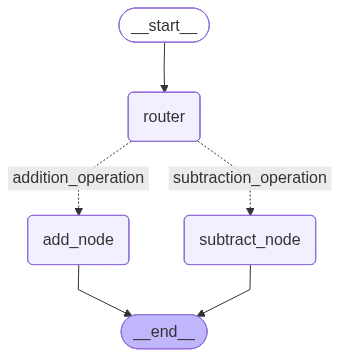

In [5]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
initial_state: AgentState = {'num1': 10, 'num2': 5, 'operation': '+'}
app.invoke(initial_state)

{'num1': 10, 'num2': 5, 'operation': '+', 'result': 15}

In [9]:
second_state: AgentState = {'num1': 20, 'num2': 8, 'operation': '-'}
app.invoke(second_state)

{'num1': 20, 'num2': 8, 'operation': '-', 'result': 12}